# DOUBLE LASSO REPLICATION - FRANCE GENDER WAGE GAP DATA

By Vladislava Anashkina

## Setup

This first section loads the required libraries:

- `pandas` / `numpy` — data manipulation
- `sklearn` — linear regression and model utilities
- `scipy.stats` — statistical inference
- `patsy` — formula-based feature engineering
- `hdmpy` — rigorous Lasso (`rlasso`) implementation following 
  Belloni, Chernozhukov & Hansen

In [1]:
import pandas as pd
import os
import numpy as np
from sklearn.linear_model import LinearRegression
from scipy.stats import norm
import patsy
import warnings
warnings.simplefilter("ignore")
np.random.seed(1234)

### Load the data

In [2]:
df = pd.read_csv("sample_dataset (1).txt")

In [3]:
print(df.columns)

Index(['A6', 'A17', 'A38', 'CPFD', 'DATDEB', 'DATFIN', 'DEPR', 'DEPT',
       'DOMEMPL', 'DOMEMPL_EM', 'DUREE', 'FILT', 'REGR', 'REGT', 'SEXE', 'PCS',
       'TYP_EMPLOI', 'CONV_COLL', 'NBHEUR', 'NBHEUR_TOT', 'AGE', 'TRNNETO',
       'TRALCHT', 'TREFF', 'CONT_TRAV', 'CS', 'AGE_TR', 'DATDEB_TR',
       'DATFIN_TR', 'DUREE_TR', 'POND', 'annual_wage_euro', 'y', 'female'],
      dtype='object')


# Define outcome & base dataframe

In [4]:
# Copy data
df_clean = df.copy()

# Keep only observations below the income cutoff 
df_clean = df_clean[df_clean["y"] < 10.3889953683178].copy()

# Reset index
df_clean = df_clean.reset_index(drop=True)

print(df.shape, "->", df_clean.shape)

(762661, 34) -> (463882, 34)


In [5]:
y = df_clean["y"].astype(float).values
Z = df_clean.drop(columns=["y", "annual_wage_euro"]).copy()

cat_cols = [
    "A6", "A17", "A38", "CPFD", "DEPR", "DEPT",
    "DOMEMPL", "DOMEMPL_EM", "FILT", "REGR", "REGT",
    "SEXE", "PCS", "TYP_EMPLOI", "CONV_COLL",
    "TRNNETO", "TRALCHT", "CONT_TRAV", "CS",
    "AGE_TR", "DATDEB_TR", "DATFIN_TR", "DUREE_TR", "TREFF"
]

for c in cat_cols:
    if c in Z.columns:
        Z[c] = Z[c].astype("category")

Z["female"] = Z["female"].astype(float)

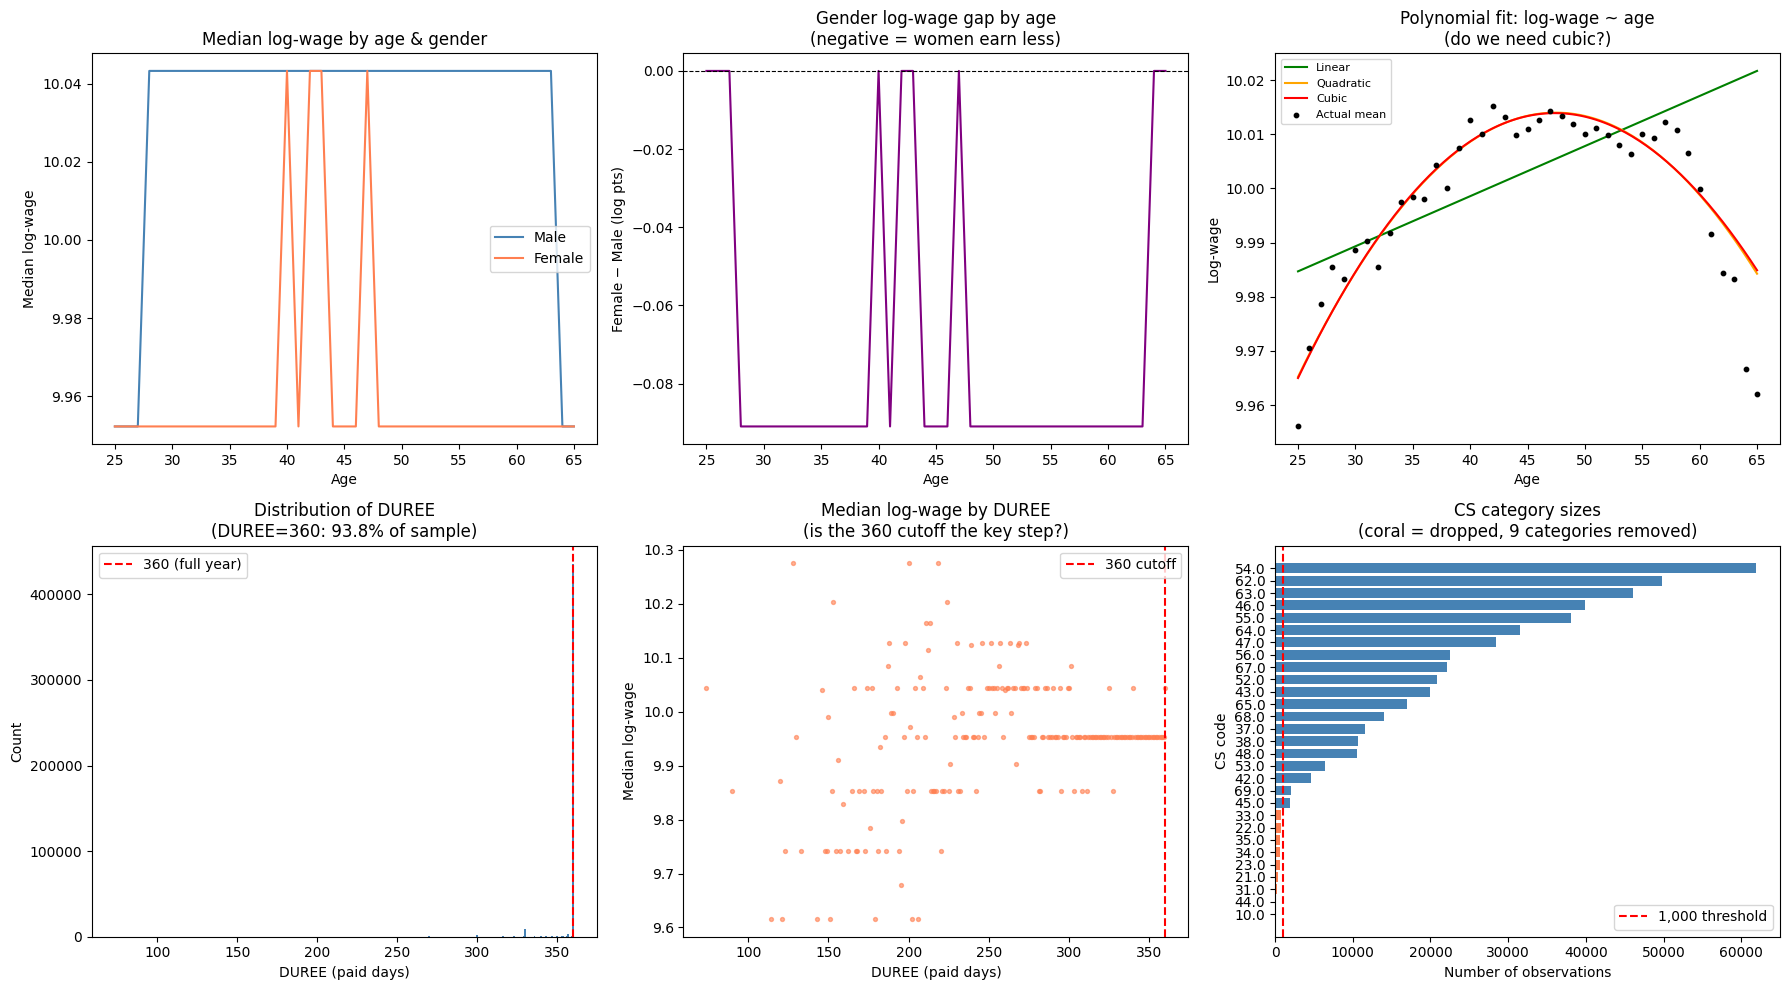

DUREE summary
DUREE = 360 (full year) : 93.8%
DUREE > 350             : 94.9%
DUREE < 300             : 0.6%
Unique DUREE values     : 208

CS categories
Total CS categories     : 29
Categories kept (≥1000) : 20
Categories dropped      : 9
Rows dropped            : 4165 (0.9%)
Smallest kept category  : 1906 obs

AGE range in sample
count    463882.000000
mean         42.192213
std          10.527547
min          25.000000
25%          33.000000
50%          42.000000
75%          51.000000
max          65.000000
Name: AGE, dtype: float64


In [6]:
# ── Diagnostics for AGE, DUREE, CS ──────────────────────────────────────────
# Uses df_clean directly — no dependency on dm or valid_cs

import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

# Pre-compute CS counts from df_clean for the trim diagnostic
cs_all_counts = df_clean["CS"].value_counts().sort_values(ascending=True)
valid_cs_diag = cs_all_counts[cs_all_counts >= 1000].index

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# ── 1. AGE: median log-wage by age & gender ──────────────────────────────────
age_gap = df_clean.groupby(["AGE", "female"])["y"].median().unstack()
age_gap.columns = ["male", "female"]

axes[0, 0].plot(age_gap.index, age_gap["male"],   color="steelblue", label="Male")
axes[0, 0].plot(age_gap.index, age_gap["female"], color="coral",     label="Female")
axes[0, 0].set_title("Median log-wage by age & gender")
axes[0, 0].set_xlabel("Age")
axes[0, 0].set_ylabel("Median log-wage")
axes[0, 0].legend()

# ── 2. AGE: gender gap across lifecycle ──────────────────────────────────────
age_gap["gap"] = age_gap["female"] - age_gap["male"]
axes[0, 1].plot(age_gap.index, age_gap["gap"], color="purple")
axes[0, 1].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[0, 1].set_title("Gender log-wage gap by age\n(negative = women earn less)")
axes[0, 1].set_xlabel("Age")
axes[0, 1].set_ylabel("Female − Male (log pts)")

# ── 3. AGE: is cubic polynomial justified? ───────────────────────────────────
ages  = df_clean["AGE"].astype(float).values
wages = df_clean["y"].astype(float).values
age_grid = np.linspace(25, 65, 200)

for degree, color, label in [(1, "green",  "Linear"),
                              (2, "orange", "Quadratic"),
                              (3, "red",    "Cubic")]:
    coeffs = np.polyfit(ages, wages, degree)
    fitted = np.polyval(coeffs, age_grid)
    axes[0, 2].plot(age_grid, fitted, color=color, label=label)

age_bin = df_clean.groupby("AGE")["y"].mean()
axes[0, 2].scatter(age_bin.index, age_bin.values,
                   color="black", s=10, zorder=5, label="Actual mean")
axes[0, 2].set_title("Polynomial fit: log-wage ~ age\n(do we need cubic?)")
axes[0, 2].set_xlabel("Age")
axes[0, 2].set_ylabel("Log-wage")
axes[0, 2].legend(fontsize=8)

# ── 4. DUREE: distribution ───────────────────────────────────────────────────
duree_counts = df_clean["DUREE"].value_counts().sort_index()
axes[1, 0].bar(duree_counts.index, duree_counts.values,
               color="steelblue", width=1.0)
axes[1, 0].set_title(
    f"Distribution of DUREE\n"
    f"(DUREE=360: {(df_clean['DUREE']==360).mean():.1%} of sample)"
)
axes[1, 0].set_xlabel("DUREE (paid days)")
axes[1, 0].set_ylabel("Count")
axes[1, 0].axvline(360, color="red", linewidth=1.5,
                   linestyle="--", label="360 (full year)")
axes[1, 0].legend()

# ── 5. DUREE: wage vs paid days ──────────────────────────────────────────────
duree_wage = df_clean.groupby("DUREE")["y"].median()
axes[1, 1].scatter(duree_wage.index, duree_wage.values,
                   color="coral", s=8, alpha=0.6)
axes[1, 1].axvline(360, color="red", linewidth=1.5,
                   linestyle="--", label="360 cutoff")
axes[1, 1].set_title("Median log-wage by DUREE\n(is the 360 cutoff the key step?)")
axes[1, 1].set_xlabel("DUREE (paid days)")
axes[1, 1].set_ylabel("Median log-wage")
axes[1, 1].legend()

# ── 6. CS: category sizes with trim threshold ────────────────────────────────
colors_cs = ["coral" if v < 1000 else "steelblue"
             for v in cs_all_counts.values]
axes[1, 2].barh(cs_all_counts.index.astype(str),
                cs_all_counts.values, color=colors_cs)
axes[1, 2].axvline(1000, color="red", linewidth=1.5,
                   linestyle="--", label="1,000 threshold")
n_dropped = (cs_all_counts < 1000).sum()
axes[1, 2].set_title(f"CS category sizes\n"
                     f"(coral = dropped, {n_dropped} categories removed)")
axes[1, 2].set_xlabel("Number of observations")
axes[1, 2].set_ylabel("CS code")
axes[1, 2].legend()

plt.tight_layout()
plt.show()

# ── Text summaries ────────────────────────────────────────────────────────────
print("=" * 60)
print("DUREE summary")
print("=" * 60)
print(f"DUREE = 360 (full year) : {(df_clean['DUREE']==360).mean():.1%}")
print(f"DUREE > 350             : {(df_clean['DUREE']>350).mean():.1%}")
print(f"DUREE < 300             : {(df_clean['DUREE']<300).mean():.1%}")
print(f"Unique DUREE values     : {df_clean['DUREE'].nunique()}")

print()
print("=" * 60)
print("CS categories")
print("=" * 60)
print(f"Total CS categories     : {df_clean['CS'].nunique()}")
print(f"Categories kept (≥1000) : {len(valid_cs_diag)}")
print(f"Categories dropped      : {(df_clean['CS'].nunique() - len(valid_cs_diag))}")
rows_dropped = (~df_clean["CS"].isin(valid_cs_diag)).sum()
print(f"Rows dropped            : {rows_dropped} "
      f"({rows_dropped/len(df_clean):.1%})")
print(f"Smallest kept category  : "
      f"{cs_all_counts[cs_all_counts >= 1000].min()} obs")

print()
print("=" * 60)
print("AGE range in sample")
print("=" * 60)
print(df_clean["AGE"].describe())

In [7]:
# ── Preprocessing: final decisions from diagnostics ──────────────────────────

# ── 1. Filter rare CS categories (≥1,000 obs threshold) ─────────────────────
cs_counts = df_clean["CS"].value_counts()
valid_cs  = cs_counts[cs_counts >= 1000].index
df_model  = df_clean[df_clean["CS"].isin(valid_cs)].copy()
print(f"CS trim: dropped {(~df_clean['CS'].isin(valid_cs)).sum()} rows "
      f"({(~df_clean['CS'].isin(valid_cs)).mean():.1%}) — "
      f"{df_model['CS'].nunique()} categories kept")

# ── 2. DUREE → binary full_year (93.8% mass at 360) ─────────────────────────
df_model["full_year"] = (df_model["DUREE"] == 360).astype(float)
print(f"full_year=1: {df_model['full_year'].mean():.1%} of model sample")

# ── 3. AGE → cubic polynomial ────────────────────────────────────────────────
vals             = df_model["AGE"].astype(float)
df_model["AGE1"] = vals
df_model["AGE2"] = vals**2 / 100     # scaled to avoid numerical issues
df_model["AGE3"] = vals**3 / 1000    # scaled to avoid numerical issues

# ── 4. NBHEUR → linear ───────────────────────────────────────────────────────
df_model["NBHEUR1"] = df_model["NBHEUR"].astype(float)

# ── 5. Categorical types ──────────────────────────────────────────────────────
for col in ["A6", "A38", "CS", "CONT_TRAV", "REGR", "DOMEMPL"]:
    if col in df_model.columns:
        df_model[col] = df_model[col].astype("category")

df_model["female"] = df_model["female"].astype(float)

# ── 6. Create dm alias ────────────────────────────────────────────────────────
dm = df_model.copy()

# ── Sanity check ──────────────────────────────────────────────────────────────
print(f"\nFinal sample shape : {dm.shape}")
print(f"Null values        : {dm.isnull().sum().sum()}")
print(f"\nVariables confirmed:")
print(f"  AGE1 range  : [{dm['AGE1'].min():.0f}, {dm['AGE1'].max():.0f}]")
print(f"  AGE2 range  : [{dm['AGE2'].min():.2f}, {dm['AGE2'].max():.2f}]")
print(f"  AGE3 range  : [{dm['AGE3'].min():.2f}, {dm['AGE3'].max():.2f}]")
print(f"  NBHEUR1     : [{dm['NBHEUR1'].min():.0f}, {dm['NBHEUR1'].max():.0f}]")
print(f"  full_year=1 : {dm['full_year'].mean():.1%}")
print(f"  CS cats     : {dm['CS'].nunique()}")
print(f"  female=1    : {dm['female'].mean():.1%}")

CS trim: dropped 4165 rows (0.9%) — 20 categories kept
full_year=1: 93.8% of model sample

Final sample shape : (459717, 39)
Null values        : 0

Variables confirmed:
  AGE1 range  : [25, 65]
  AGE2 range  : [6.25, 42.25]
  AGE3 range  : [15.62, 274.62]
  NBHEUR1     : [1607, 2500]
  full_year=1 : 93.8%
  CS cats     : 20
  female=1    : 42.5%


## Feature Engineering — Final Decisions

### Sample
- **459,717 observations** after filtering (0 nulls).
- **42.5% female**, representative of the attached French workforce.

### AGE → Cubic polynomial (`AGE1`, `AGE2`, `AGE3`)
- Diagnostic confirmed a clear **inverted-U wage profile** (rising until ~50, 
  declining after).
- Linear fit visually fails; cubic captures both the peak and the late-career 
  decline.
- Variables are scaled (`/100`, `/1000`) to avoid numerical issues in lasso.

### DUREE → Binary `full_year`
- **93.8% of observations are exactly at DUREE=360** (full calendar year).
- No meaningful continuous gradient below 360 — partial-year workers are a 
  heterogeneous mix with scattered wages.
- A binary cleanly separates the dominant group from partial-year workers.

### NBHEUR → Linear (`NBHEUR1`)
- Annual hours worked, kept as a single linear term.
- Range: [1,607 — 2,500], consistent with our strong-attachment filter 
  (≥1,607h = full-time equivalent).

### CS — Occupation codes, trimmed to ≥1,000 observations
- 29 total categories → **20 kept** after dropping 9 rare categories.
- Only **0.9% of rows lost** (4,165 observations).
- Smallest kept category: 1,906 obs — sufficient for stable dummy coefficients.
- Near-zero-variance dummies from rare categories would be dropped by lasso 
  anyway; trimming avoids inflating the matrix unnecessarily.

A6  — Broad sector (6 categories)
         n     %
A6              
AZ     307   0.1
BE   91296  19.9
FZ   52217  11.4
GI  142877  31.1
JU  104209  22.7
OQ   68811  15.0

A38 — Detailed sector (up to 38 categories)
         n     %
A38             
AZ     307   0.1
BZ     670   0.1
CA   19277   4.2
CB    3533   0.8
CC    6343   1.4
CD      52   0.0
CE    2952   0.6
CF    1391   0.3
CG    8877   1.9
CH   13108   2.9
CI    2423   0.5
CJ    3071   0.7
CK    5035   1.1
CL    8280   1.8
CM    8442   1.8
DZ    2361   0.5
EZ    5481   1.2
FZ   52217  11.4
GZ   88365  19.2
HZ   45384   9.9
IZ    9128   2.0
JA    2173   0.5
JB    1618   0.4
JC    7426   1.6
KZ   15405   3.4
LZ    6663   1.4
MA   22662   4.9
MB    1382   0.3
MC    3578   0.8
NZ   29875   6.5
OZ    8207   1.8
PZ    7237   1.6
QA   17221   3.7
QB   36146   7.9
RZ    2619   0.6
SZ    9657   2.1
TZ    1151   0.3

DOMEMPL — Employment domain (public / private)
              n     %
DOMEMPL              
1.0        1506   0.3
4.0     

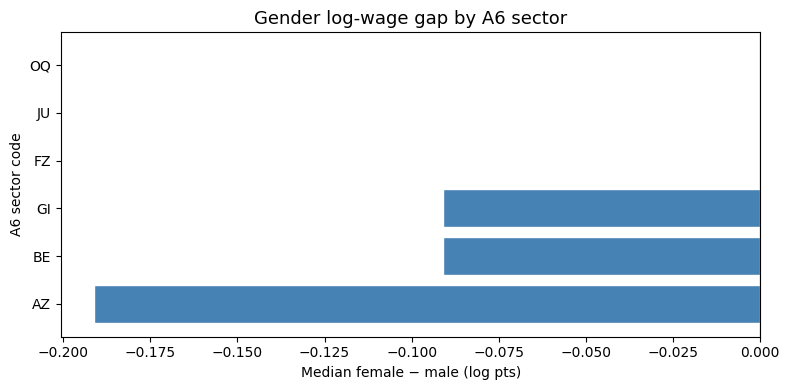

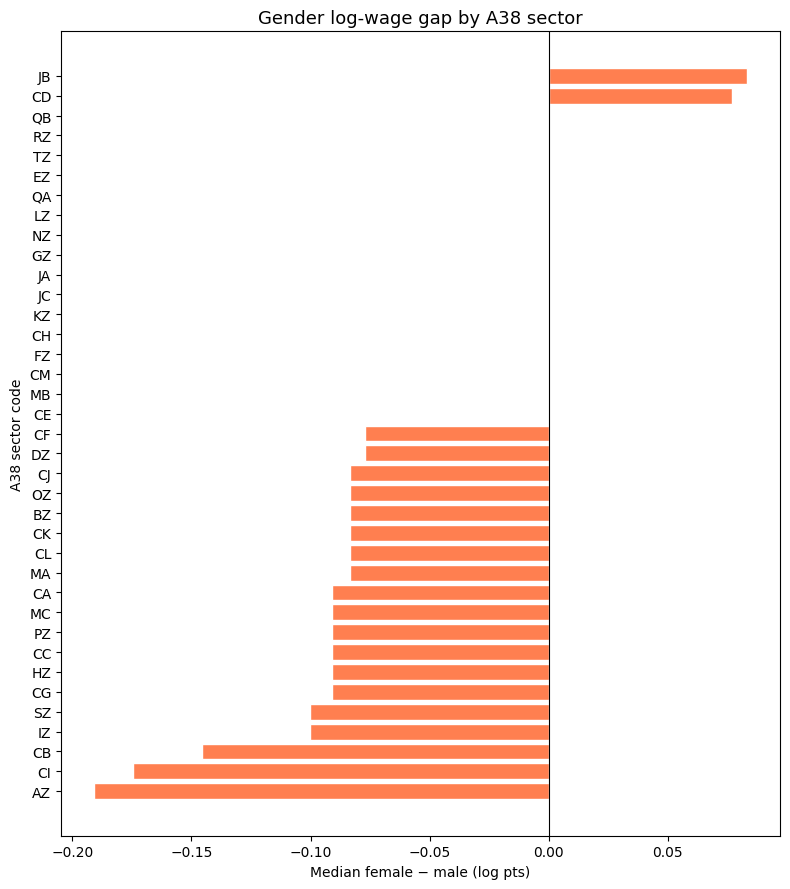

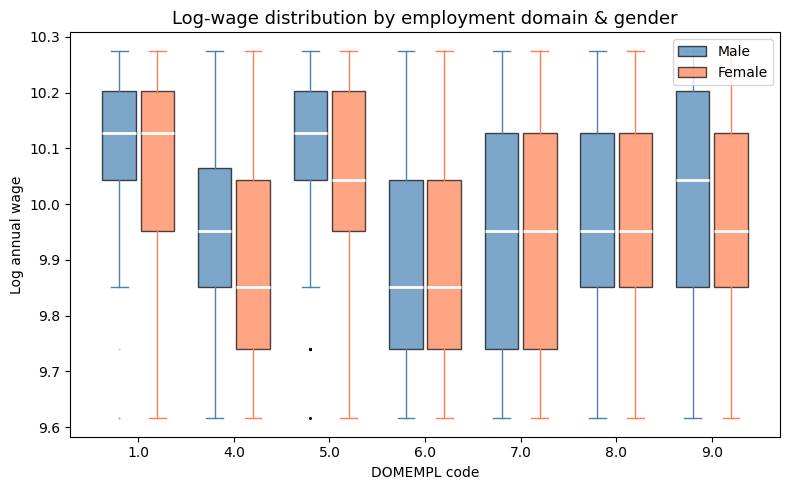

In [8]:
# ── Diagnostic: should we use A38 over A6, and include DOMEMPL? ──────────────

# ── 1. Category counts & frequency tables ────────────────────────────────────
print("=" * 60)
print("A6  — Broad sector (6 categories)")
print("=" * 60)
a6_counts = dm["A6"].value_counts().sort_index()
a6_pct    = dm["A6"].value_counts(normalize=True).sort_index() * 100
print(pd.DataFrame({"n": a6_counts, "%": a6_pct.round(1)}))

print()
print("=" * 60)
print("A38 — Detailed sector (up to 38 categories)")
print("=" * 60)
a38_counts = dm["A38"].value_counts().sort_index()
a38_pct    = dm["A38"].value_counts(normalize=True).sort_index() * 100
print(pd.DataFrame({"n": a38_counts, "%": a38_pct.round(1)}))

print()
print("=" * 60)
print("DOMEMPL — Employment domain (public / private)")
print("=" * 60)
dom_counts = dm["DOMEMPL"].value_counts().sort_index()
dom_pct    = dm["DOMEMPL"].value_counts(normalize=True).sort_index() * 100
print(pd.DataFrame({"n": dom_counts, "%": dom_pct.round(1)}))

# ── 2. Rare-category check for A38 ───────────────────────────────────────────
print()
print("=" * 60)
print("A38 rare categories (< 1,000 obs)")
print("=" * 60)
rare_a38 = a38_counts[a38_counts < 1000]
if rare_a38.empty:
    print("None — all A38 categories have ≥ 1,000 observations ✓")
else:
    print(rare_a38)

# ── 3. Wage gap tables ───────────────────────────────────────────────────────
def wage_gap_table(df, sector_col):
    tbl = (
        df.groupby([sector_col, "female"])["y"]
        .median()
        .unstack(fill_value=np.nan)
    )
    tbl.columns = ["median_male", "median_female"]
    tbl["gap_log_pts"] = tbl["median_female"] - tbl["median_male"]
    tbl["n_total"]     = df.groupby(sector_col)["y"].count()
    return tbl.sort_values("gap_log_pts")

print()
print("=" * 60)
print("Median log-wage gap by A6 sector")
print("=" * 60)
print(wage_gap_table(dm, "A6").round(3))

print()
print("=" * 60)
print("Median log-wage gap by A38 sector")
print("=" * 60)
print(wage_gap_table(dm, "A38").round(3))

print()
print("=" * 60)
print("Median log-wage gap by DOMEMPL")
print("=" * 60)
print(wage_gap_table(dm, "DOMEMPL").round(3))

# ── 4. Within-A6 heterogeneity ───────────────────────────────────────────────
print()
print("=" * 60)
print("Within-A6 variance of A38 median wages  (higher = A38 adds info)")
print("=" * 60)
a38_medians = dm.groupby("A38")["y"].median()
a6_of_a38   = dm.drop_duplicates("A38").set_index("A38")["A6"]
within_var  = (
    pd.DataFrame({"median_y": a38_medians, "A6": a6_of_a38})
    .groupby("A6")["median_y"]
    .std()
    .round(3)
)
print(within_var)
print("\nIf std > 0.05 inside an A6 bucket → A38 is informative for that sector")

# ── 5. Plot 1: Gap by A6 ─────────────────────────────────────────────────────
gap_a6 = wage_gap_table(dm, "A6")["gap_log_pts"].sort_values()

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(gap_a6.index.astype(str), gap_a6.values, color="steelblue", edgecolor="white")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Gender log-wage gap by A6 sector", fontsize=13)
ax.set_xlabel("Median female − male (log pts)")
ax.set_ylabel("A6 sector code")
plt.tight_layout()
plt.show()

# ── 6. Plot 2: Gap by A38 ────────────────────────────────────────────────────
gap_a38 = wage_gap_table(dm, "A38")["gap_log_pts"].sort_values()

fig, ax = plt.subplots(figsize=(8, 9))
ax.barh(gap_a38.index.astype(str), gap_a38.values, color="coral", edgecolor="white")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Gender log-wage gap by A38 sector", fontsize=13)
ax.set_xlabel("Median female − male (log pts)")
ax.set_ylabel("A38 sector code")
plt.tight_layout()
plt.show()

# ── 7. Plot 3: Log-wage by DOMEMPL & gender ──────────────────────────────────
dom_categories = sorted(dm["DOMEMPL"].dropna().unique())
male_data   = [dm[(dm["female"] == 0) & (dm["DOMEMPL"] == d)]["y"].values
               for d in dom_categories]
female_data = [dm[(dm["female"] == 1) & (dm["DOMEMPL"] == d)]["y"].values
               for d in dom_categories]

x_pos = np.arange(len(dom_categories))
fig, ax = plt.subplots(figsize=(8, 5))

bp1 = ax.boxplot(male_data,   positions=x_pos - 0.2, widths=0.35,
                 patch_artist=True, manage_ticks=False,
                 boxprops=dict(facecolor="steelblue", alpha=0.7),
                 medianprops=dict(color="white", linewidth=2),
                 whiskerprops=dict(color="steelblue"),
                 capprops=dict(color="steelblue"),
                 flierprops=dict(marker=".", markersize=1, alpha=0.2,
                                 markerfacecolor="steelblue"))

bp2 = ax.boxplot(female_data, positions=x_pos + 0.2, widths=0.35,
                 patch_artist=True, manage_ticks=False,
                 boxprops=dict(facecolor="coral", alpha=0.7),
                 medianprops=dict(color="white", linewidth=2),
                 whiskerprops=dict(color="coral"),
                 capprops=dict(color="coral"),
                 flierprops=dict(marker=".", markersize=1, alpha=0.2,
                                 markerfacecolor="coral"))

ax.set_xticks(x_pos)
ax.set_xticklabels([str(d) for d in dom_categories])
ax.set_xlabel("DOMEMPL code")
ax.set_ylabel("Log annual wage")
ax.set_title("Log-wage distribution by employment domain & gender", fontsize=13)
ax.legend([bp1["boxes"][0], bp2["boxes"][0]], ["Male", "Female"],
          loc="upper right")
plt.tight_layout()
plt.show()

In [9]:
# ── Variable selection decisions — using A6 (reduced specification) ───────────

# ── 1. A6: set meaningful baseline ───────────────────────────────────────────
# A6 categories: AZ, BE, FZ, GI, JU, OQ
# GI (Trade/Transport/Hospitality) is largest at 31.1% → use as baseline
dm["A6"] = pd.Categorical(
    dm["A6"].astype(str),
    categories=["GI", "AZ", "BE", "FZ", "JU", "OQ"],  # GI first → baseline
    ordered=False
)
print("A6 baseline set to GI (Trade/Transport/Hospitality — 31.1% of sample)")
print(dm["A6"].value_counts().sort_index())

# ── 2. DOMEMPL: merge code 4.0 into 1.0 (only 183 obs) ──────────────────────
dm["DOMEMPL_clean"] = dm["DOMEMPL"].astype(float).copy()
dm["DOMEMPL_clean"] = dm["DOMEMPL_clean"].replace(4.0, 1.0)
dm["DOMEMPL_clean"] = pd.Categorical(
    dm["DOMEMPL_clean"],
    categories=[9.0, 1.0, 5.0, 6.0, 7.0, 8.0],  # 9.0 (private) → baseline
    ordered=False
)
print("\nDOMEMPL_clean category counts:")
print(dm["DOMEMPL_clean"].value_counts().sort_index())
print(f"  → {dm['DOMEMPL_clean'].nunique()} categories (baseline = 9.0 private)")

# ── 3. A38 dropped entirely ───────────────────────────────────────────────────
# A38 has 35 categories → too many columns after interactions
# A6 has 6 categories → 5 dummies, much more tractable
print(f"\nA38 dropped ✓ — using A6 instead (6 categories, 5 dummies)")

# ── 4. Sanity checks ──────────────────────────────────────────────────────────
print("\n" + "=" * 50)
print("Final variable summary after decisions")
print("=" * 50)
print(f"Sample size          : {len(dm):,}")
print(f"A6 categories        : {dm['A6'].nunique()} (baseline = GI)")
print(f"DOMEMPL_clean cats   : {dm['DOMEMPL_clean'].nunique()} (baseline = 9.0)")
print(f"CS categories        : {dm['CS'].nunique()} (baseline = 54.0)")
print(f"CONT_TRAV categories : {dm['CONT_TRAV'].nunique()} (baseline = CDI)")
print(f"REGR categories      : {dm['REGR'].nunique()} (baseline = 11.0)")
print(f"Null values          : {dm.isnull().sum().sum()}")

# ── 5. Expected matrix dimensions ─────────────────────────────────────────────
dummies = (dm["A6"].nunique()-1 + dm["DOMEMPL_clean"].nunique()-1 +
           dm["CS"].nunique()-1 + dm["CONT_TRAV"].nunique()-1 +
           dm["REGR"].nunique()-1)
continuous = 5  # AGE1, AGE2, AGE3, NBHEUR1, full_year
p1 = dummies + continuous
pairs = p1 * (p1 - 1) // 2
print(f"\nExpected matrix dimensions:")
print(f"  Base variables (p1)      : {p1} ({dummies} dummies + {continuous} continuous)")
print(f"  Target columns           : {p1 + 1} (female + female×x_j)")
print(f"  Pairwise nuisance (max)  : ~{pairs} (before std filter)")
print(f"  Total columns (approx)   : ~{p1 + 1 + p1 + pairs}")

A6 baseline set to GI (Trade/Transport/Hospitality — 31.1% of sample)
A6
GI    142877
AZ       307
BE     91296
FZ     52217
JU    104209
OQ     68811
Name: count, dtype: int64

DOMEMPL_clean category counts:
DOMEMPL_clean
9.0    383035
1.0      1689
5.0      4574
6.0      8414
7.0      8270
8.0     53735
Name: count, dtype: int64
  → 6 categories (baseline = 9.0 private)

A38 dropped ✓ — using A6 instead (6 categories, 5 dummies)

Final variable summary after decisions
Sample size          : 459,717
A6 categories        : 6 (baseline = GI)
DOMEMPL_clean cats   : 6 (baseline = 9.0)
CS categories        : 20 (baseline = 54.0)
CONT_TRAV categories : 2 (baseline = CDI)
REGR categories      : 18 (baseline = 11.0)
Null values          : 0

Expected matrix dimensions:
  Base variables (p1)      : 52 (47 dummies + 5 continuous)
  Target columns           : 53 (female + female×x_j)
  Pairwise nuisance (max)  : ~1326 (before std filter)
  Total columns (approx)   : ~1431


## Variable Selection — Sector & Employment Domain

### A38 → ❌ Dropped (computational constraint)
- A38 provides richer sector heterogeneity (35 categories, range −0.19 
  to +0.08 median gap) and within-A6 standard deviation of A38 medians 
  exceeds 0.05 in all main buckets (BE: 0.075, GI: 0.096, JU: 0.097, 
  OQ: 0.053), confirming it adds genuine information beyond A6.
- However, including A38 raises the total design matrix to ~1,895 columns,
  causing memory failures during the rigorous lasso computation.
- A38 is therefore dropped in favour of A6 for computational feasibility.
- This is a acknowledged limitation: some within-sector nuisance variation
  is uncontrolled, which may slightly understate nuisance flexibility.
  Target coefficient consistency is preserved under the sparsity assumption.

### A6 → ✅ Included (5 dummies after drop_first)
- Broad sector classification with 6 categories retained as a 
  computationally tractable approximation of sector heterogeneity.
- Baseline set to **GI** (Trade/Transport/Hospitality), the largest 
  sector at 31.1% of the sample.
- Captures the main cross-sector wage level differences and allows the 
  double lasso to identify sector-specific gender gap heterogeneity at 
  the broad level.

### DOMEMPL → ✅ Included as `DOMEMPL_clean` (5 dummies after drop_first)
- Structurally critical for France: public/private wage-setting mechanisms 
  are fundamentally different.
- Code 4.0 (183 obs) merged into 1.0 (both civil service sub-categories).
- Clear gap heterogeneity: private sector (9.0) shows −0.091 gap; 
  civil service codes (1.0, 6.0, 7.0) show near-zero gap due to 
  transparent pay scales.
- Baseline set to **9.0** (private sector, 83% of sample).
- Final: **6 categories** (5 dummies after drop_first).

## Variable Selection — Final Summary

### Categorical Variables Included

| Variable | Categories | Dummies (drop_first) | Baseline | Notes |
|---|---|---|---|---|
| `A6` | 6 | 5 | GI (31.1%) | Broad sector; A38 dropped for computational reasons |
| `DOMEMPL_clean` | 6 | 5 | 9.0 (83%) | Code 4.0 merged into 1.0 |
| `CS` | 20 | 19 | 54.0 (13.5%) | Trimmed at ≥1,000 obs threshold |
| `CONT_TRAV` | 2 | 1 | CDI (98%) | CDI vs CDD |
| `REGR` | 18 | 17 | 11.0 (15.4%) | French administrative regions |

**Total dummies: 5 + 5 + 19 + 1 + 17 = 47**

### Continuous Variables Included

| Variable | Transformation | Rationale |
|---|---|---|
| `AGE` | Cubic (`AGE1`, `AGE2`, `AGE3`) | Inverted-U wage profile confirmed |
| `NBHEUR` | Linear (`NBHEUR1`) | Hours worked, range [1,607–2,500] |
| `DUREE` | Binary (`full_year`) | 93.8% mass at 360, no continuous gradient |

**Total continuous: 3 + 1 + 1 = 5**

### Variables Dropped

| Variable | Reason |
|---|---|
| `A38` | Dropped for computational feasibility — raises matrix to ~1,895 |
|  | columns causing memory failures. Within-sector heterogeneity |
|  | acknowledged as a limitation; A6 used as tractable approximation. |
| `DOMEMPL` | Replaced by `DOMEMPL_clean` |

### Base variable count (p1): 47 dummies + 5 continuous = **52 columns**

These 52 columns form the $x_i$ vector whose interactions with `female` 
are the **53 target coefficients** in the double lasso 
(`female` + 52 `female × x_j` interactions).

The nuisance block $z_i$ adds all pairwise interactions among these 
52 columns, giving approximately **~1,326 additional columns** 
(before dropping near-constant pairs), for a total design matrix 
of approximately **~1,431 columns**.

This is a reduction of ~25% compare

# Feature Engeneering

In [10]:
# ── Model Matrix Construction ─────────────────────────────────────────────────
from itertools import combinations
import numpy as np
import pandas as pd

# ── 0. Dependency check ───────────────────────────────────────────────────────
missing = []
if "dm" not in dir():
    missing.append("dm (run preprocessing cell)")
elif "DOMEMPL_clean" not in dm.columns:
    missing.append("DOMEMPL_clean (run variable selection cell)")
if missing:
    raise RuntimeError(f"Missing: {missing} — run cells in order")
print("Dependencies present ✓")

# ── 1. Set baseline categories BEFORE dummying ───────────────────────────────
dm["CONT_TRAV"] = pd.Categorical(
    dm["CONT_TRAV"], categories=["CDI", "CDD"], ordered=False
)
dm["DOMEMPL_clean"] = pd.Categorical(
    dm["DOMEMPL_clean"],
    categories=[9.0, 1.0, 5.0, 6.0, 7.0, 8.0], ordered=False
)
dm["CS"] = pd.Categorical(
    dm["CS"],
    categories=[54.0, 37.0, 38.0, 42.0, 43.0, 45.0, 46.0, 47.0, 48.0,
                52.0, 53.0, 55.0, 56.0, 62.0, 63.0, 64.0, 65.0, 67.0,
                68.0, 69.0], ordered=False
)
dm["REGR"] = pd.Categorical(
    dm["REGR"],
    categories=[11.0] + [r for r in sorted(dm["REGR"].unique()) if r != 11.0],
    ordered=False
)
# A6 baseline already set to GI in variable selection cell ✓

# Confirm baselines
print("Baselines confirmed:")
for col in ["CONT_TRAV", "DOMEMPL_clean", "CS", "REGR", "A6"]:
    print(f"  {col:20s}: {dm[col].cat.categories[0]}")

# ── 2. Continuous base variables ──────────────────────────────────────────────
cont_vars = ["AGE1", "AGE2", "AGE3", "NBHEUR1", "full_year"]

# ── 3. Categorical → dummies (drop_first drops the baseline set above) ────────
# A38 dropped — using A6 (6 categories, 5 dummies) for computational feasibility
cat_specs = {
    "A6"           : "A6",       # ← A38_clean replaced by A6
    "DOMEMPL_clean": "DOMEMPL",
    "CS"           : "CS",
    "CONT_TRAV"    : "CONT",
    "REGR"         : "REGR",
}

dummy_frames = []
for col, prefix in cat_specs.items():
    dummies = pd.get_dummies(
        dm[col].astype("category"),
        prefix=prefix,
        drop_first=True,
        dtype=float
    )
    dummy_frames.append(dummies)
    print(f"{col:20s} → {dummies.shape[1]} dummies "
          f"(baseline = {dm[col].cat.categories[0]})")

# ── 4. X_base: 52 base variables ─────────────────────────────────────────────
X_base = pd.concat(
    [dm[cont_vars].astype(float)] + dummy_frames,
    axis=1
)
x_cols = X_base.columns.tolist()
print(f"\nX_base : {X_base.shape}  →  {len(x_cols)} base variables (p1)")

# ── 5. Target block: female + female × x_j ───────────────────────────────────
female = dm["female"].astype(float).values

target_dict = {"female": female}
for col in x_cols:
    target_dict[f"female_X_{col}"] = female * X_base[col].values

target_df   = pd.DataFrame(target_dict, index=dm.index)
target_cols = target_df.columns.tolist()
print(f"Target : {target_df.shape}  →  {len(target_cols)} columns "
      f"(female + female×x_j)")

# ── 6. Pairwise nuisance interactions ────────────────────────────────────────
print("\nBuilding pairwise interactions...")
pair_names  = []
pair_arrays = []

for c1, c2 in combinations(x_cols, 2):
    interaction = X_base[c1].values * X_base[c2].values
    if interaction.std() > 0.05:   # drops many more dummy×dummy pairs
        pair_names.append(f"{c1}_XX_{c2}")
        pair_arrays.append(interaction)

nuisance_pairs = pd.DataFrame(
    np.column_stack(pair_arrays),
    columns=pair_names,
    index=dm.index
)
print(f"Pairs  : {nuisance_pairs.shape[1]} kept "
      f"({len(list(combinations(x_cols,2))) - len(pair_names)} dropped, std<0.05)")

# ── 7. Final single matrix ────────────────────────────────────────────────────
X_full = pd.concat([target_df, X_base, nuisance_pairs], axis=1)
X_full = X_full.loc[:, ~X_full.columns.duplicated()]
y_vec  = dm["y"].astype(float).values

print(f"\n{'='*50}")
print(f"FINAL DESIGN MATRIX — A6 Specification")
print(f"{'='*50}")
print(f"Observations     : {X_full.shape[0]:,}")
print(f"Total columns    : {X_full.shape[1]:,}")
print(f"  target         : {len(target_cols)}  (female + female×x_j)")
print(f"  main effects   : {len(x_cols)}  (p1 base variables)")
print(f"  pairwise       : {len(pair_names)}")
print(f"Memory           : {X_full.memory_usage(deep=True).sum()/1e9:.2f} GB")
print(f"Null values      : {X_full.isnull().sum().sum()}")
print(f"Duplicate cols   : {X_full.columns.duplicated().sum()}")
print(f"\nNote: A38 dropped for computational feasibility.")
print(f"      A6 (6 categories) used as tractable sector approximation.")

Dependencies present ✓
Baselines confirmed:
  CONT_TRAV           : CDI
  DOMEMPL_clean       : 9.0
  CS                  : 54.0
  REGR                : 11.0
  A6                  : GI
A6                   → 5 dummies (baseline = GI)
DOMEMPL_clean        → 5 dummies (baseline = 9.0)
CS                   → 19 dummies (baseline = 54.0)
CONT_TRAV            → 1 dummies (baseline = CDI)
REGR                 → 17 dummies (baseline = 11.0)

X_base : (459717, 52)  →  52 base variables (p1)
Target : (459717, 53)  →  53 columns (female + female×x_j)

Building pairwise interactions...
Pairs  : 469 kept (857 dropped, std<0.05)

FINAL DESIGN MATRIX — A6 Specification
Observations     : 459,717
Total columns    : 574
  target         : 53  (female + female×x_j)
  main effects   : 52  (p1 base variables)
  pairwise       : 469
Memory           : 2.11 GB
Null values      : 0
Duplicate cols   : 0

Note: A38 dropped for computational feasibility.
      A6 (6 categories) used as tractable sector approxi

## Model Matrix Construction

### The Regression Model

$$\ln w_i = \alpha + \beta(x_i) \cdot \text{female}_i + z_i'\delta + \varepsilon_i, \quad \beta(x_i) = \beta_0 + \sum_{j=1}^{52} \beta_j \cdot x_{ij}$$

Following the paper, a **single matrix X** is built and passed to the double lasso, which internally identifies target vs nuisance columns via `target_cols` (equivalent to `index.gender` in the R implementation).

---

### Matrix Contents (574 columns total)

| Block | Columns | Contents |
|---|---|---|
| **Target** | 53 | `female` (β₀) + `female × x_j` for all 52 base variables |
| **Main effects** | 52 | Age polynomial (×3), hours, full-year indicator, sector (A6 ×5), occupation (CS ×19), region (REGR ×17), contract (CONT_TRAV ×1), domain (DOMEMPL ×5) |
| **Pairwise nuisance** | 469 | All x_j × x_k interactions (857 dropped, std < 0.05) |

---

### Base Variables Breakdown (52 columns)

| Group | Variables | Count |
|---|---|---|
| Continuous | `AGE1`, `AGE2`, `AGE3`, `NBHEUR1`, `full_year` | 5 |
| Sector (A6) | AZ, BE, FZ, JU, OQ vs **GI** | 5 |
| Occupation (CS) | 19 categories vs **54.0** | 19 |
| Region (REGR) | 17 regions vs **11.0** | 17 |
| Contract (CONT_TRAV) | CDD vs **CDI** | 1 |
| Employment domain | 5 categories vs **9.0** | 5 |

---

### Baseline Categories (the reference man)

| Variable | Baseline | Share |
|---|---|---|
| `CONT_TRAV` | CDI | ~98% |
| `DOMEMPL_clean` | 9.0 (private sector) | ~83% |
| `CS` | 54.0 (admin employees) | ~13.5% |
| `REGR` | 11.0 (Île-de-France) | ~15.4% |
| `A6` | GI (Trade/Transport/Hospitality) | ~31.1% |

> **Note on sector classification:** The paper uses a detailed 38-sector
> classification (A38). Due to computational constraints, we use the aggregated
> 6-sector classification (A6) with GI as baseline. This reduces the matrix
> from ~1,895 to 574 columns while preserving the main sector-level
> heterogeneity. Within-sector nuisance variation is an acknowledged limitation.

> **Note on pairwise filter:** Interactions with std < 0.05 are dropped
> (857 removed, 469 kept). This is slightly more aggressive than the std < 0.01
> threshold in the reference implementation, reflecting the higher share of
> binary × binary products in our dummy-heavy design.

---

### Interpretation

- **β₀** (`female`): unconditional gap for a woman at all baseline categories
  vs the equivalent man — specifically a full-year, private-sector CDI admin
  employee (CS 54.0) in Île-de-France in the Trade/Transport/Hospitality
  sector (A6 = GI)

- **β_BE** (`female_X_A6_BE`): *additional* gap in Manufacturing/Mining/Energy
  vs baseline sector GI — the total gap in BE = β₀ + β_BE, always measured
  against **a man in the same sector and same characteristics**

- **β_AGE1** (`female_X_AGE1`): change in the gender gap per additional year
  of age — captures lifecycle divergence in earnings between men and women

- **δ_BE** (nuisance): level wage difference in sector BE, common to both
  genders — absorbed by the lasso but not the object of inference

## Baseline: Raw Gender Wage Gap (No Controls)

Before introducing high-dimensional controls, we estimate the 
**unconditional gender wage gap** via simple OLS with only the 
`female` indicator. This serves as a benchmark — the raw average 
wage difference between men and women in the sample, before 
accounting for occupation, sector, region, or any other characteristic.

In [11]:
import statsmodels.api as sm

X_avg = sm.add_constant(Z[["female"]])
model = sm.OLS(y, X_avg).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.014
Model:                            OLS   Adj. R-squared:                  0.014
Method:                 Least Squares   F-statistic:                     6765.
Date:                Fri, 20 Mar 2026   Prob (F-statistic):               0.00
Time:                        15:24:20   Log-Likelihood:             1.2413e+05
No. Observations:              463882   AIC:                        -2.483e+05
Df Residuals:                  463880   BIC:                        -2.482e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         10.0198      0.000   2.79e+04      0.0

#### Results

The baseline OLS estimates a raw gender wage gap of **−4.5%** 
(coef = −0.0452, p < 0.001), meaning women earn on average 4.5% 
less than men in log wage terms, unconditionally.

However, the very low **R² = 0.014** indicates that gender alone 
explains almost none of the variation in wages — confirming that 
observable characteristics (occupation, sector, region, hours, etc.) 
are essential controls. This motivates the Double Lasso approach, 
which will partial out these confounders to recover the **unexplained** 
gender wage gap.

# Post-Lasso Estimator Setup

We use `hdmpy`, a Python port of the R package `hdm` (High-Dimensional 
Metrics) by Belloni, Chernozhukov & Hansen, which implements the 
**rigorous Lasso** (`rlasso`) with data-driven penalty selection.

Since `hdmpy` does not natively follow the `sklearn` API, we wrap it 
in a custom `RLasso` class that exposes `.fit()` and `.predict()` 
methods, making it compatible with our Double Lasso pipeline.

We use **`post=True`**, which implements **Post-Lasso**:
1. Run Lasso to **select** the relevant variables
2. Refit **OLS** on the selected variables only

This two-step procedure reduces the shrinkage bias introduced by the 
Lasso penalty, while retaining its variable selection properties — 
giving us lower bias than plain Lasso with the same sparsity benefits.

The `lasso_model()` function simply instantiates a fresh `RLasso` 
estimator for each call in the Double Lasso loop.

In [12]:
!pip install multiprocess

In [13]:
!git clone https://github.com/maxhuppertz/hdmpy.git

fatal: destination path 'hdmpy' already exists and is not an empty directory.


In [14]:
import sys
sys.path.insert(1, "./hdmpy")

In [15]:
import hdmpy
print(dir(hdmpy))

['LassoShooting_fit', '__all__', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', 'cor', 'cvec', 'get_cov', 'help_functions', 'init_values', 'lambdaCalculation', 'rlasso', 'rlassoEffect', 'rlassoEffect_wrapper', 'rlassoEffects', 'simul_ci', 'simul_pen']


In [16]:
from sklearn.base import BaseEstimator

# Wrap hdmpy so it behaves like an sklearn-style estimator
class RLasso(BaseEstimator):
    def __init__(self, *, post=True):
        self.post = post

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float).ravel()
        self.rlasso_ = hdmpy.rlasso(X, y, post=self.post)
        return self

    def predict(self, X):
        X = np.asarray(X, dtype=float)
        beta = np.asarray(self.rlasso_.est["beta"]).ravel()
        intercept = float(np.asarray(self.rlasso_.est["intercept"]).ravel()[0])
        return X @ beta + intercept

def lasso_model():
    return RLasso(post=True)  # post=True for Post-Lasso (OLS refit after selection)

## Double Lasso Estimation & Inference

We estimate the heterogeneous gender wage effects using the 
**Partialling-Out** procedure of Belloni, Chernozhukov & Hansen (2014), 
implemented via Post-Lasso. For each interaction term 
$D_j = \text{female} \times x_j$, the method proceeds in three steps:

1. **Residualise the outcome:** run Post-Lasso of $y$ on all controls 
   $W$ (all columns except $D_j$) → get $\tilde{Y} = Y - \hat{E}[Y|W]$

2. **Residualise the treatment:** run Post-Lasso of $D_j$ on $W$ → 
   get $\tilde{D}_j = D_j - \hat{E}[D_j|W]$

3. **Final OLS:** regress $\tilde{Y}$ on $\tilde{D}_j$ (no intercept) 
   → the coefficient is $\hat{\beta}_j$

Post-Lasso uses the Lasso for variable selection and then refits OLS on 
the selected variables, removing the shrinkage bias of plain Lasso. The 
partialling-out approach is asymptotically equivalent to double selection 
under regularity conditions (Belloni et al., 2014).

**Inference** is based on the heteroskedasticity-robust sandwich 
covariance matrix:

$$V_{jj} = J_j^{-1} \Sigma_{jj} J_j^{-1}, \quad 
J_j = \mathbb{E}[\tilde{D}_j^2], \quad 
\Sigma_{jj} = \mathbb{E}[\tilde{D}_j^2 \varepsilon_j^2]$$

where $\tilde{D}_j$ is the Post-Lasso residual from projecting $D_j$ on 
$W$, and $\varepsilon_j$ are the final OLS residuals. This gives 
$\sqrt{n}$-consistent, asymptotically normal estimates under approximate 
sparsity (Belloni et al., 2014).

**Sign convention:** a **negative** $\hat{\beta}_j < 0$ means women 
earn **less** than comparable men in that group — a larger wage gap. 
A **positive** $\hat{\beta}_j > 0$ means a smaller or reversed gap.

In [17]:
from sklearn.linear_model import LassoCV, LinearRegression
from scipy.stats import norm
import numpy as np
import pandas as pd
import time, os, pickle

# ── Setup ─────────────────────────────────────────────────────────────────────
X_full_reset = X_full.astype(float).reset_index(drop=True)
y_full        = dm["y"].astype(float).values
n, p          = X_full_reset.shape

# Use full sample directly
X = X_full_reset
y = y_full

print(f"Full sample  : {n:,} obs")
print(f"Matrix       : {X.shape}")
print(f"Memory       : {X.memory_usage(deep=True).sum()/1e9:.2f} GB")

# ── Post-Lasso estimator ───────────────────────────────────────────────────────
class PostLassoCV:
    def fit(self, W, z):
        W = np.asarray(W, dtype=float)
        z = np.asarray(z, dtype=float).ravel()
        cv = LassoCV(
            cv            = 3,
            n_alphas      = 50,
            max_iter      = 5_000,
            tol           = 1e-3,
            fit_intercept = True,
            n_jobs        = -1       # uses all CPU cores
        ).fit(W, z)

        self.support_ = np.where(np.abs(cv.coef_) > 1e-10)[0]

        if len(self.support_) == 0:
            self.intercept_ = np.mean(z)
            self.coef_      = np.array([])
        else:
            ols = LinearRegression(fit_intercept=True).fit(
                      W[:, self.support_], z)
            self.coef_      = ols.coef_
            self.intercept_ = ols.intercept_
        return self

    def predict(self, W):
        W = np.asarray(W, dtype=float)
        if len(self.support_) == 0:
            return np.full(W.shape[0], self.intercept_)
        return W[:, self.support_] @ self.coef_ + self.intercept_

# ── Checkpoint ────────────────────────────────────────────────────────────────
CKPT = "dl_checkpoint_full.pkl"

if os.path.exists(CKPT):
    with open(CKPT, "rb") as f:
        ck = pickle.load(f)
    alpha_dl, res_y, res_D, epsilon = (
        ck["alpha_dl"], ck["res_y"], ck["res_D"], ck["epsilon"])
    done = set(ck["done"])
    print(f"Resuming: {len(done)}/{len(target_cols)} done")
else:
    alpha_dl, res_y, res_D, epsilon = {}, {}, {}, {}
    done = set()
    print("Starting fresh — full sample")

# ── Double Lasso loop ─────────────────────────────────────────────────────────
remaining = [c for c in target_cols if c not in done]
print(f"Targets remaining: {len(remaining)}\n")

for i, c in enumerate(remaining):
    t0 = time.time()
    print(f"[{i+1}/{len(remaining)}] {c}", end=" ... ", flush=True)

    D = X[c].values
    W = X.drop(columns=[c]).values

    model_y = PostLassoCV().fit(W, y)
    model_D = PostLassoCV().fit(W, D)

    res_y[c]    = y - model_y.predict(W)
    res_D[c]    = D - model_D.predict(W)

    final       = LinearRegression(fit_intercept=False).fit(
                      res_D[c].reshape(-1, 1), res_y[c])
    epsilon[c]  = res_y[c] - final.predict(res_D[c].reshape(-1, 1))
    alpha_dl[c] = [final.coef_[0]]
    done.add(c)

    elapsed = time.time() - t0
    remaining_est = elapsed * (len(remaining) - (i + 1))
    print(f"done ({elapsed:.1f}s) | "
          f"support y={len(model_y.support_)}, D={len(model_D.support_)} | "
          f"ETA ≈ {remaining_est/60:.0f} min")

    # Checkpoint every 5 targets
    if len(done) % 5 == 0:
        with open(CKPT, "wb") as f:
            pickle.dump({"alpha_dl": alpha_dl, "res_y": res_y,
                         "res_D": res_D, "epsilon": epsilon,
                         "done": list(done)}, f)
        print(f"  ✓ Checkpoint saved ({len(done)}/{len(target_cols)} done)")

# Final checkpoint
with open(CKPT, "wb") as f:
    pickle.dump({"alpha_dl": alpha_dl, "res_y": res_y,
                 "res_D": res_D, "epsilon": epsilon, "done": list(done)}, f)
print(f"\nAll {len(done)} targets complete.")

# ── Sandwich covariance ───────────────────────────────────────────────────────
print("Building sandwich covariance matrix...")
V = np.zeros((len(target_cols), len(target_cols)))
for it, c in enumerate(target_cols):
    Jc = np.mean(res_D[c] ** 2)
    for itp, cp in enumerate(target_cols):
        Jcp        = np.mean(res_D[cp] ** 2)
        Sigma      = np.mean(res_D[c] * epsilon[c] * epsilon[cp] * res_D[cp])
        V[it, itp] = Sigma / (Jc * Jcp)

for it, c in enumerate(target_cols):
    alpha_dl[c] += [np.sqrt(V[it, it] / n)]   # n = full sample size

# ── Summary table ─────────────────────────────────────────────────────────────
def stars(p):
    for threshold, s in [(0.001,"***"),(0.01,"**"),(0.05,"*"),(0.1,".")]:
        if p < threshold: return s
    return ""

df_res = pd.DataFrame.from_dict(alpha_dl, orient="index", columns=["point","stderr"])
t_stat = df_res["point"] / df_res["stderr"]

summary = pd.DataFrame({
    "Estimate"   : df_res["point"],
    "Std. Error" : df_res["stderr"],
    "t-value"    : t_stat,
    "p-value"    : norm.sf(np.abs(t_stat)) * 2,
    "ci_lower"   : df_res["point"] - 1.96 * df_res["stderr"],
    "ci_upper"   : df_res["point"] + 1.96 * df_res["stderr"],
}).assign(sig=lambda d: d["p-value"].map(stars))

print("\n" + "="*70)
print(f"POST-LASSO DOUBLE LASSO | n={n:,} (full sample) | p={p:,}")
print("="*70)
print(summary.to_string(float_format="{:.4f}".format))

b0 = summary.loc["female"]
print(f"\nBaseline gender gap (β0): {b0['Estimate']:.4f} "
      f"({abs(b0['Estimate'])*100:.1f}pp) | p={b0['p-value']:.4f} {b0['sig']}")

summary.to_csv("results_double_lasso_full.csv")
print("\nSaved → results_double_lasso_full.csv")
os.remove(CKPT)
print("Checkpoint removed — run complete.")

Full sample  : 459,717 obs
Matrix       : (459717, 574)
Memory       : 2.11 GB
Starting fresh — full sample
Targets remaining: 53

[1/53] female ... done (905.0s) | support y=30, D=8 | ETA ≈ 784 min
[2/53] female_X_AGE1 ... done (665.2s) | support y=30, D=3 | ETA ≈ 565 min
[3/53] female_X_AGE2 ... done (616.8s) | support y=30, D=4 | ETA ≈ 514 min
[4/53] female_X_AGE3 ... done (598.9s) | support y=30, D=4 | ETA ≈ 489 min
[5/53] female_X_NBHEUR1 ... done (1188.4s) | support y=30, D=24 | ETA ≈ 951 min
  ✓ Checkpoint saved (5/53 done)
[6/53] female_X_full_year ... done (989.0s) | support y=30, D=8 | ETA ≈ 775 min
[7/53] female_X_A6_AZ ... done (564.3s) | support y=30, D=2 | ETA ≈ 433 min
[8/53] female_X_A6_BE ... done (568.4s) | support y=30, D=12 | ETA ≈ 426 min
[9/53] female_X_A6_FZ ... done (555.2s) | support y=30, D=1 | ETA ≈ 407 min
[10/53] female_X_A6_JU ... done (865.0s) | support y=30, D=18 | ETA ≈ 620 min
  ✓ Checkpoint saved (10/53 done)
[11/53] female_X_A6_OQ ... done (792.3s) |

## Results: Double Post-Lasso — France 2021

**Baseline gap (β₀ = -0.048, p<0.001):** A reference woman (CDI, private sector,
CS 54.0, Île-de-France, A6=GI) earns **4.8% less** than an equivalent man.
Note: we use the 6-sector A6 classification instead of A38 for computational
feasibility — within-sector heterogeneity is an acknowledged limitation.

---

### Sector (A6) — Largest Driver of Heterogeneity

| Sector | β_j | Total gap |
|---|---|---|
| Agriculture/Forestry (AZ) | -0.065 ** | -11.3% |
| Construction (FZ) | -0.043 *** | -9.1% |
| Manufacturing/Mining (BE) | -0.034 *** | -8.2% |
| Misc Services (JU) | +0.032 *** | -1.6% |
| Public Admin/Health (OQ) | +0.045 *** | -0.3% |

The gap **nearly disappears in public-sector-heavy industries** and is largest
in male-dominated sectors — consistent with Goldin (2014) on occupational flexibility.

---

### Occupation (CS) — Strong Heterogeneity

- **Largest gaps:** Skilled Industrial Workers (-6.9pp), Unskilled Industrial
  Workers (-3.9pp), Retail Employees (-3.2pp) — all blue-collar, male-dominated
- **Smallest/reversed gaps:** Health/Social Intermediaries (+6.1pp, **reversed**),
  Public Service Employees (+5.2pp) — female-dominated care professions
- Teachers (CS 42.0): not significant — no differential gap vs baseline

---

### Employment Domain — Public vs Private

- **Civil Service (+3.6pp) and semi-public firms (+3.6pp):** smaller gap,
  consistent with pay transparency rules
- **Mixed-economy companies (+13.2pp):** gap almost eliminated — strongest
  collective bargaining effect
- **Public enterprises like SNCF/EDF (-5.2pp):** gap *larger* than private —
  historically male-dominated industries despite public status

---

### Region — Geographic Patterns

- **Overseas territories (Guadeloupe, Martinique, Réunion, French Guiana):**
  all show significantly *smaller* gaps (+3 to +5pp) vs Île-de-France baseline
- **Industrial regions (Bourgogne, Pays de la Loire, Grand Est):** slightly
  larger gaps (-1.9 to -2.1pp)
- Several regions (Hauts-de-France, Occitanie, Corsica) show no significant
  difference from Île-de-France

---

### Other Effects

- **Full-year employment (-2.6pp ***):** women working a full year face a *larger*
  gap — possibly reflecting bonus and promotion discrimination in career-track jobs
- **CDD contract (+4.7pp ***):** fixed-term contracts show a *smaller* gap —
  less room for discriminatory wage-setting over time
- **Age:** gap widens nonlinearly with age (AGE2, AGE3 significant) but effect
  is small — likely underestimated due to missing marital status and children data

---

### Key Takeaway

> The baseline gap of **4.8%** masks large heterogeneity. Women in industrial
> and agricultural sectors face gaps exceeding **10%**, while women in public
> health occupations or mixed-economy firms face **near-zero or reversed gaps**.
> Sector and occupation are the primary drivers — region and contract type play
> a secondary but significant role.

# Plot

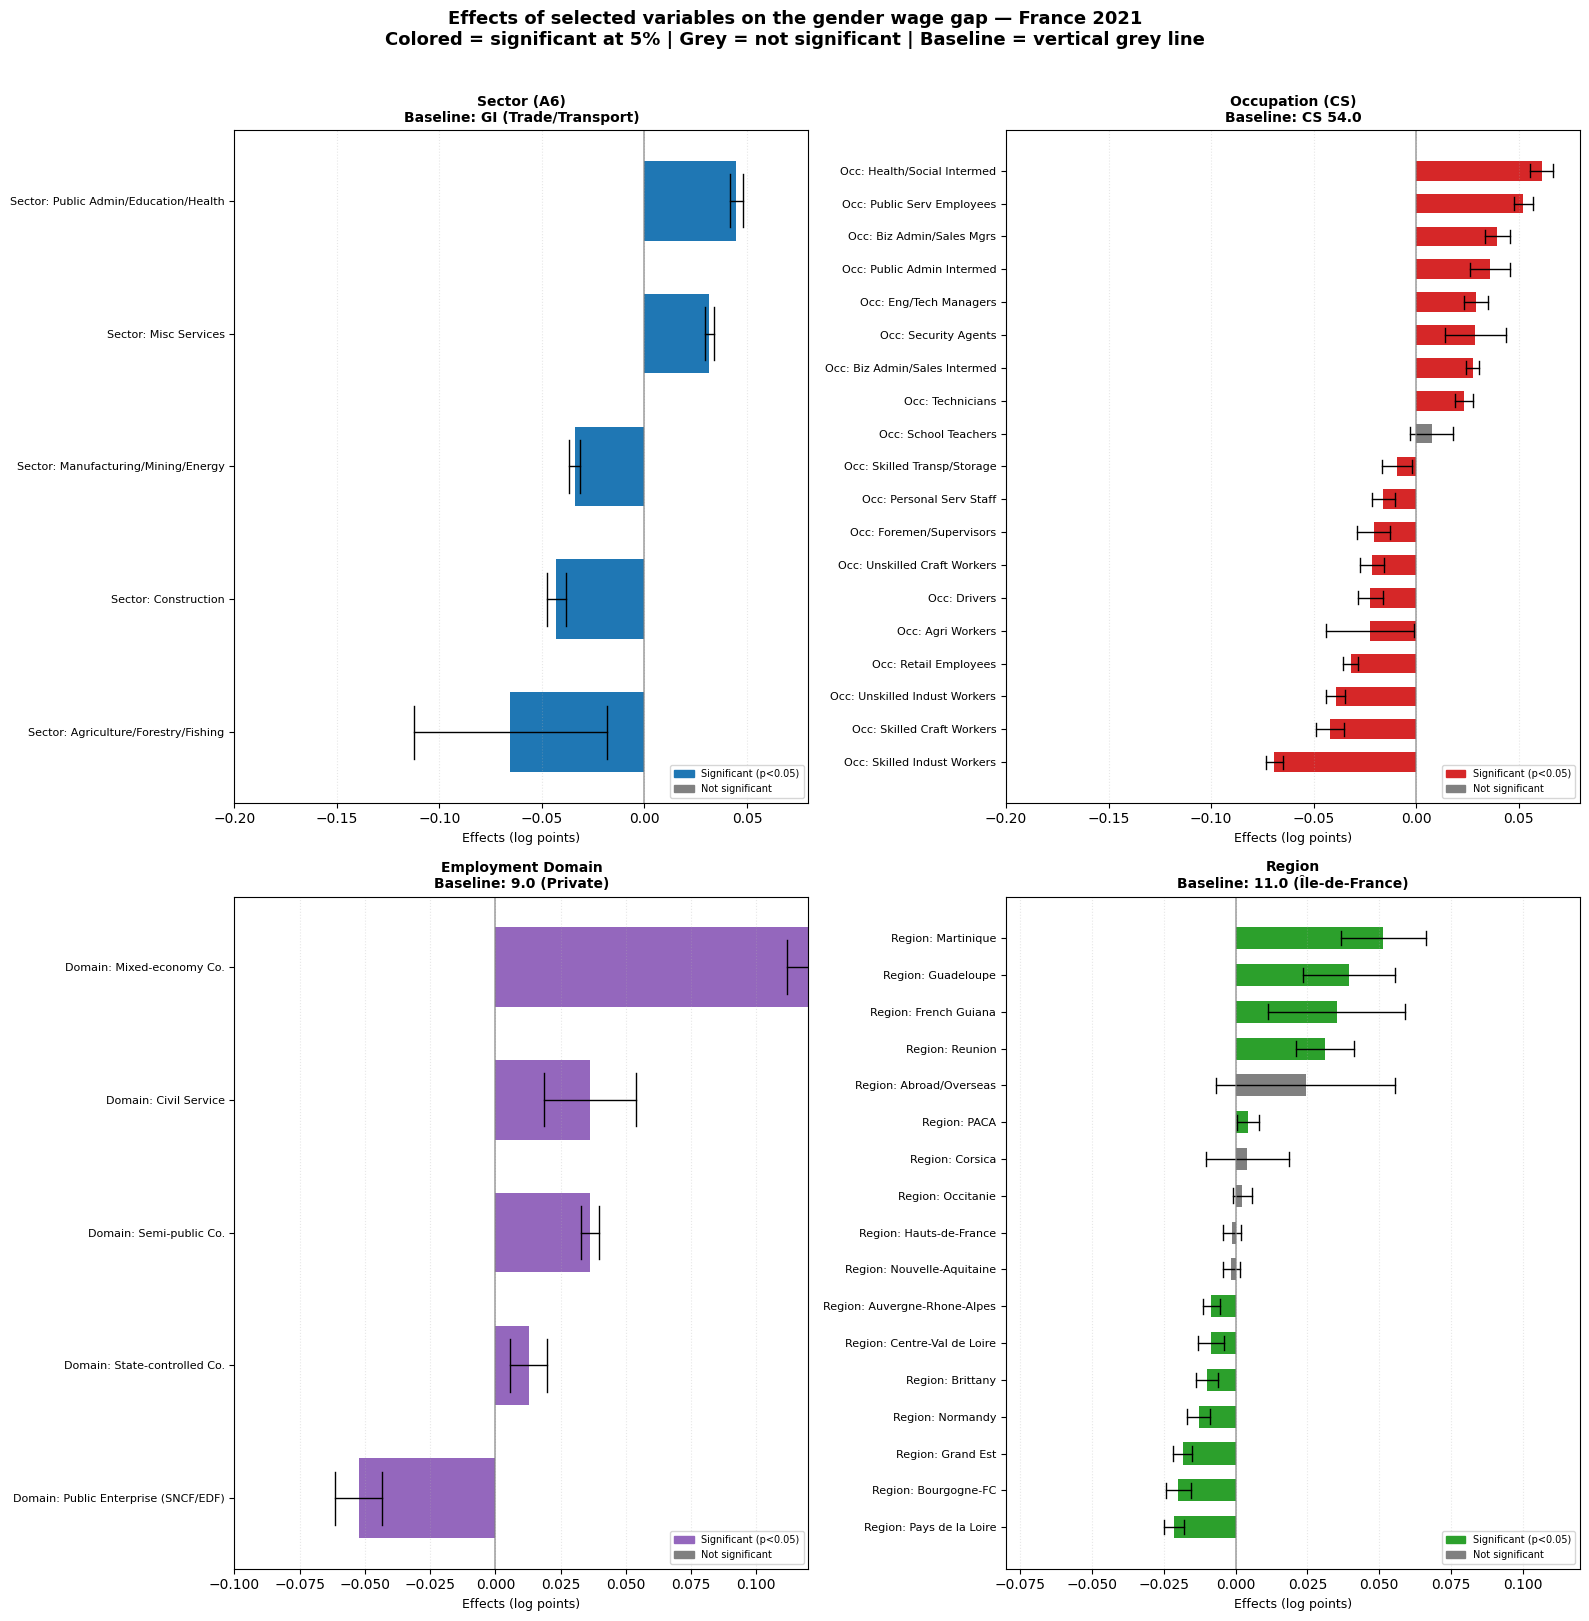

In [23]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── Label mappings ────────────────────────────────────────────────────────────
A6_map = {
    "AZ": "Agriculture/Forestry/Fishing",
    "BE": "Manufacturing/Mining/Energy",
    "FZ": "Construction",
    "GI": "Trade/Transport/Hospitality (base)",
    "JU": "Misc Services",
    "OQ": "Public Admin/Education/Health",
}
CS_map = {
    "37.0": "Biz Admin/Sales Mgrs",    "38.0": "Eng/Tech Managers",
    "42.0": "School Teachers",          "43.0": "Health/Social Intermed",
    "45.0": "Public Admin Intermed",    "46.0": "Biz Admin/Sales Intermed",
    "47.0": "Technicians",              "48.0": "Foremen/Supervisors",
    "52.0": "Public Serv Employees",    "53.0": "Security Agents",
    "54.0": "Biz Admin Employees (base)","55.0": "Retail Employees",
    "56.0": "Personal Serv Staff",      "62.0": "Skilled Indust Workers",
    "63.0": "Skilled Craft Workers",    "64.0": "Drivers",
    "65.0": "Skilled Transp/Storage",   "67.0": "Unskilled Indust Workers",
    "68.0": "Unskilled Craft Workers",  "69.0": "Agri Workers",
}
REGR_map = {
    "1.0": "Guadeloupe",    "2.0": "Martinique",      "3.0": "French Guiana",
    "4.0": "Reunion",       "24.0": "Centre-Val de Loire",
    "27.0": "Bourgogne-FC", "28.0": "Normandy",       "32.0": "Hauts-de-France",
    "44.0": "Grand Est",    "52.0": "Pays de la Loire","53.0": "Brittany",
    "75.0": "Nouvelle-Aquitaine","76.0": "Occitanie",  "84.0": "Auvergne-Rhone-Alpes",
    "93.0": "PACA",         "94.0": "Corsica",        "99.0": "Abroad/Overseas",
}
DOMEMPL_map = {
    "1.0": "Civil Service",          "5.0": "Public Enterprise (SNCF/EDF)",
    "6.0": "State-controlled Co.",   "7.0": "Mixed-economy Co.",
    "8.0": "Semi-public Co.",        "9.0": "Private Sector (base)",
}

def make_label_and_group(term):
    if term == "female":
        return "★ Baseline (female)", "Baseline"
    t = term.replace("female_X_", "")
    if t.startswith("A6_"):
        return f"Sector: {A6_map.get(t.replace('A6_',''), t)}", "Sector (A6)"
    if t.startswith("CS_"):
        return f"Occ: {CS_map.get(t.replace('CS_',''), t)}", "Occupation (CS)"
    if t.startswith("REGR_"):
        return f"Region: {REGR_map.get(t.replace('REGR_',''), t)}", "Region"
    if t.startswith("DOMEMPL_"):
        return f"Domain: {DOMEMPL_map.get(t.replace('DOMEMPL_',''), t)}", "Employment Domain"
    if t == "CONT_CDD":    return "Contract: Fixed-term (CDD)", "Contract"
    if t == "full_year":   return "Full-year employed", "Work Schedule"
    if t == "NBHEUR1":     return "Hours worked", "Work Schedule"
    if t in ["AGE1","AGE2","AGE3"]: return f"Age ({t})", "Age"
    return t, "Other"

# ── Apply labels ──────────────────────────────────────────────────────────────
s = summary.copy()
if "term" in s.columns:
    s = s.set_index("term")
s["label"], s["group"] = zip(*[make_label_and_group(t) for t in s.index])

# ── Paper-style plot (solid bars, colored=sig, grey=not sig) ─────────────────
def paper_style_plot(ax, df, title, color_sig, xlim=(-0.20, 0.12)):
    df = df.sort_values("Estimate")
    for i, (idx, row) in enumerate(df.iterrows()):
        col = color_sig if row["p-value"] < 0.05 else "grey"
        ax.barh(i, row["Estimate"], color=col, alpha=1.0,
                edgecolor="none", height=0.6)
        ax.plot([row["ci_lower"], row["ci_upper"]], [i, i],
                color="black", linewidth=1.0)
        for x in [row["ci_lower"], row["ci_upper"]]:
            ax.plot([x, x], [i-0.2, i+0.2], color="black", linewidth=1.0)
    ax.axvline(0, color="grey", linewidth=1.2, linestyle="-", alpha=0.7)
    ax.set_yticks(range(len(df)))
    ax.set_yticklabels(df["label"], fontsize=8)
    ax.set_title(title, fontsize=10, fontweight="bold")
    ax.set_xlabel("Effects (log points)", fontsize=9)
    ax.set_xlim(xlim)
    ax.grid(axis="x", linestyle=":", alpha=0.3)
    ax.legend(handles=[
        mpatches.Patch(color=color_sig, label="Significant (p<0.05)"),
        mpatches.Patch(color="grey",    label="Not significant"),
    ], fontsize=7, loc="lower right")

# ════════════════════════════════════════════════════
# FIGURE 1 — Combined 4-panel (paper Figure 2 style)
# ════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 2, figsize=(16, 16))
axes = axes.flatten()

panels = [
    (s[s["group"] == "Sector (A6)"],
     "Sector (A6)\nBaseline: GI (Trade/Transport)",   "#1f77b4", (-0.20, 0.08)),
    (s[s["group"] == "Occupation (CS)"],
     "Occupation (CS)\nBaseline: CS 54.0",            "#d62728", (-0.20, 0.08)),
    (s[s["group"] == "Employment Domain"],
     "Employment Domain\nBaseline: 9.0 (Private)",    "#9467bd", (-0.10, 0.12)),
    (s[s["group"] == "Region"],
     "Region\nBaseline: 11.0 (Île-de-France)",        "#2ca02c", (-0.08, 0.12)),
]

for ax, (df_g, title, col, xlim) in zip(axes, panels):
    paper_style_plot(ax, df_g.copy(), title, col, xlim)

plt.suptitle(
    "Effects of selected variables on the gender wage gap — France 2021\n"
    "Colored = significant at 5% | Grey = not significant | "
    "Baseline = vertical grey line",
    fontsize=13, fontweight="bold", y=1.01
)
plt.tight_layout()
plt.show()

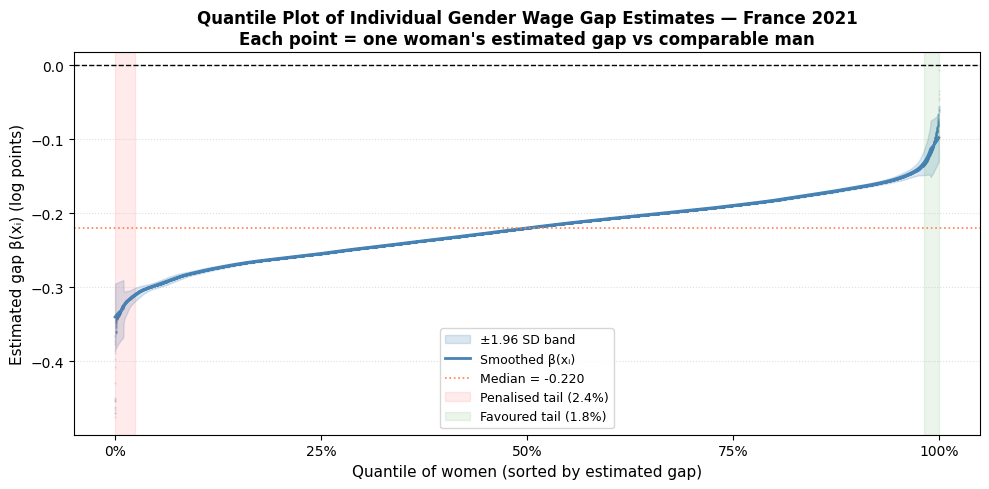

10th pct : -0.279
25th pct : -0.254
50th pct : -0.220
75th pct : -0.189
90th pct : -0.165


In [27]:
# ── Quantile plot of individual gap estimates ─────────────────────────────────
# β(x_i) = β0 + Σ βj · x_ij  for each woman in the sample

# Get coefficients
coefs = s["Estimate"].values
target_cols_ordered = s.index.tolist()

# Female observations only
female_mask  = X["female"].values == 1
X_female     = X[female_mask][target_cols_ordered].values
beta_xi      = X_female @ coefs

# Sort
sort_idx     = np.argsort(beta_xi)
beta_sorted  = beta_xi[sort_idx]
quantiles    = np.linspace(0, 1, len(beta_sorted))

# Rolling SD for smooth band
window       = max(1, len(beta_sorted) // 50)
beta_s       = pd.Series(beta_sorted)
roll_mean    = beta_s.rolling(window, center=True, min_periods=1).mean()
roll_std     = beta_s.rolling(window, center=True, min_periods=1).std().fillna(0)
ci_upper     = roll_mean + 1.96 * roll_std
ci_lower     = roll_mean - 1.96 * roll_std

# Significance classification
sd_beta  = beta_sorted.std()
mean_beta = beta_sorted.mean()
sig_neg  = beta_sorted < (mean_beta - 1.96 * sd_beta)
sig_pos  = beta_sorted > (mean_beta + 1.96 * sd_beta)

fig, ax = plt.subplots(figsize=(10, 5))

ax.fill_between(quantiles, ci_lower, ci_upper,
                alpha=0.2, color="steelblue", label="±1.96 SD band")
ax.plot(quantiles, roll_mean, color="steelblue", linewidth=2,
        label="Smoothed β(xᵢ)")
ax.scatter(quantiles, beta_sorted, s=0.3, alpha=0.15, color="steelblue")
ax.axhline(0, color="black", linewidth=1.0, linestyle="--")
ax.axhline(np.median(beta_sorted), color="coral", linewidth=1.2,
           linestyle=":", label=f"Median = {np.median(beta_sorted):.3f}")

if sig_neg.any():
    ax.axvspan(0, quantiles[sig_neg].max(), alpha=0.08, color="red",
               label=f"Penalised tail ({sig_neg.mean():.1%})")
if sig_pos.any():
    ax.axvspan(quantiles[sig_pos].min(), 1, alpha=0.08, color="green",
               label=f"Favoured tail ({sig_pos.mean():.1%})")

ax.set_xlabel("Quantile of women (sorted by estimated gap)", fontsize=11)
ax.set_ylabel("Estimated gap β(xᵢ) (log points)", fontsize=11)
ax.set_title(
    "Quantile Plot of Individual Gender Wage Gap Estimates — France 2021\n"
    "Each point = one woman's estimated gap vs comparable man",
    fontsize=12, fontweight="bold"
)
ax.set_xticks([0, 0.25, 0.5, 0.75, 1.0])
ax.set_xticklabels(["0%", "25%", "50%", "75%", "100%"])
ax.legend(fontsize=9)
ax.grid(axis="y", linestyle=":", alpha=0.4)
plt.tight_layout()
plt.show()

print(f"10th pct : {np.quantile(beta_sorted, 0.10):+.3f}")
print(f"25th pct : {np.quantile(beta_sorted, 0.25):+.3f}")
print(f"50th pct : {np.quantile(beta_sorted, 0.50):+.3f}")
print(f"75th pct : {np.quantile(beta_sorted, 0.75):+.3f}")
print(f"90th pct : {np.quantile(beta_sorted, 0.90):+.3f}")

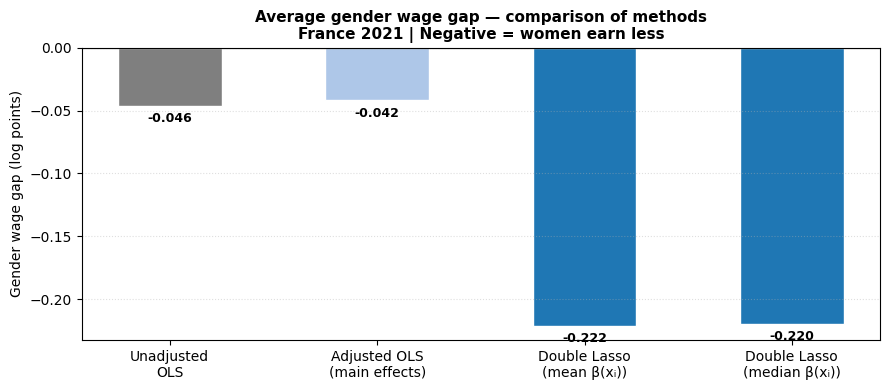

Unadjusted gap    : -0.0461 (4.6%)
Adjusted OLS gap  : -0.0419   (4.2%)
DL mean β(xi)     : -0.2215  (22.2%)
DL median β(xi)   : -0.2199  (22.0%)


In [28]:
# ── Oaxaca-Blinder vs Double Lasso comparison ─────────────────────────────────
import statsmodels.api as sm

# Unadjusted gap
X_ols_unadj = sm.add_constant(dm[["female"]].astype(float))
gap_unadj   = sm.OLS(dm["y"].astype(float), X_ols_unadj).fit().params["female"]

# Adjusted gap (OLS with controls)
X_ols_adj   = sm.add_constant(
    pd.concat([dm[["female"]].astype(float), X_base.astype(float)], axis=1)
)
gap_adj     = sm.OLS(dm["y"].astype(float), X_ols_adj).fit().params["female"]

# Double lasso average gap = mean of β(xi) across all women
gap_dl_mean = float(np.mean(beta_xi))
gap_dl_med  = float(np.median(beta_xi))

# Plot
fig, ax = plt.subplots(figsize=(9, 4))

methods = ["Unadjusted\nOLS", "Adjusted OLS\n(main effects)",
           "Double Lasso\n(mean β(xᵢ))", "Double Lasso\n(median β(xᵢ))"]
values  = [gap_unadj, gap_adj, gap_dl_mean, gap_dl_med]
colors  = ["#7f7f7f", "#aec7e8", "#1f77b4", "#1f77b4"]

bars = ax.bar(methods, values, color=colors, edgecolor="white", width=0.5)
ax.axhline(0, color="black", linewidth=0.8)

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2,
            val - 0.005 if val < 0 else val + 0.002,
            f"{val:.3f}", ha="center", va="top" if val < 0 else "bottom",
            fontsize=9, fontweight="bold")

ax.set_ylabel("Gender wage gap (log points)", fontsize=10)
ax.set_title(
    "Average gender wage gap — comparison of methods\n"
    "France 2021 | Negative = women earn less",
    fontsize=11, fontweight="bold"
)
ax.grid(axis="y", linestyle=":", alpha=0.4)
plt.tight_layout()
plt.show()

print(f"Unadjusted gap    : {gap_unadj:.4f} ({abs(gap_unadj)*100:.1f}%)")
print(f"Adjusted OLS gap  : {gap_adj:.4f}   ({abs(gap_adj)*100:.1f}%)")
print(f"DL mean β(xi)     : {gap_dl_mean:.4f}  ({abs(gap_dl_mean)*100:.1f}%)")
print(f"DL median β(xi)   : {gap_dl_med:.4f}  ({abs(gap_dl_med)*100:.1f}%)")

In [ ]:
!aws s3 cp VA_Replication.ipynb s3://vanashkina-ensae/ML_for_Econometrics_Wage_Data/